In [475]:
import torch
import torch.nn.functional as F
import imageio
import numpy as np
import cv2

In [476]:
import os
import torch
import sys
import matplotlib.pyplot as plt
from gsplat import rasterization
from optical.surface import WaterSurface
from optical.utils.test_utils import LoadDataset
from optical.utils.test_utils import combert_into_colormap, compare_rasterization_variants

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

Dataset = LoadDataset()
Dataset.set_iamge(80)
envmap_path = "hdr_040_field_prev.jpg"
# envmap_path = 'rainforest_trail_2k.exr'

means, scales, quats, opacities, colors = Dataset.get_model_param()
pixels_wo, pixels_w, camtoworld, worldtocam, cam_center, K, height, width, image_id = Dataset.get_camera_param()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.
Loading 3D point cloud from: /home/taiki/dataset/river2/refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/refraction.


In [477]:
WS = WaterSurface(
    means=means,
    scales=scales,
    quats=quats,
    opacities=opacities,
    device=device,
    
    camtoworld=camtoworld[0],
    K=K[0],
    width=width,
    height=height,
)

t_means, t_quats = WS.transform_to_appearance()
t_scales = WS.scale_correction_as_real(comp_by="edges")
map_colors = combert_into_colormap(WS.scale_correction_factor_by_edges, colormap='plasma')

rays_WS = WS.calc_ray_of_each_pixel()
WS.load_environment_map(envmap_path=envmap_path)


/home/taiki/try-papers/gsplat/optical/surface.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.n = torch.tensor(n, dtype=torch.float32, device=device, requires_grad=False)
/home/taiki/try-papers/gsplat/optical/surface.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.plane = torch.tensor(plane, dtype=torch.float32, device=device, requires_grad=False)


In [478]:
env_colors = WS.get_colors_from_envmap(rays_WS)

_ = WS.schlick_fresnel_reflectance()

cos_theta_i:
 tensor([[0.0508, 0.0508, 0.0509,  ..., 0.0509, 0.0509, 0.0508],
        [0.0518, 0.0518, 0.0519,  ..., 0.0519, 0.0519, 0.0518],
        [0.0528, 0.0528, 0.0528,  ..., 0.0529, 0.0528, 0.0528],
        ...,
        [0.8041, 0.8048, 0.8055,  ..., 0.8062, 0.8055, 0.8048],
        [0.8043, 0.8050, 0.8057,  ..., 0.8064, 0.8057, 0.8050],
        [0.8046, 0.8053, 0.8060,  ..., 0.8067, 0.8060, 0.8053]],
       device='cuda:0')


In [479]:
i = WS.cos_theta_i

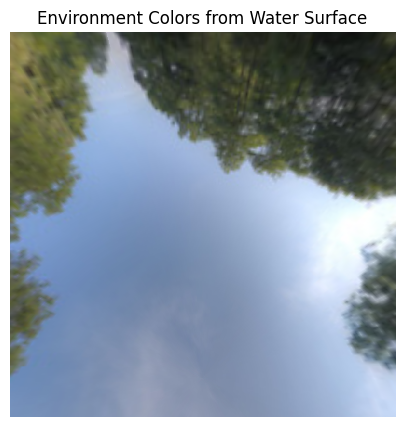

In [480]:
# refrected rays and get env map colors
reflected_rays = WS.calc_refrected_ray()
refrected_env_colors = WS.get_colors_from_envmap(reflected_rays)

refrected_env_colors_np = refrected_env_colors.cpu().numpy()
render_rgb = refrected_env_colors_np[:,:,:3]

# if the environment map has alpha channel
if refrected_env_colors_np.shape[2] == 4:
    a = refrected_env_colors_np[:,:,3].clip(0, 1)    

plt.figure(figsize=(10, 5))
plt.imshow(render_rgb, alpha=a if 'a' in locals() else None)
plt.axis('off')
plt.title('Environment Colors from Water Surface')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3444768].


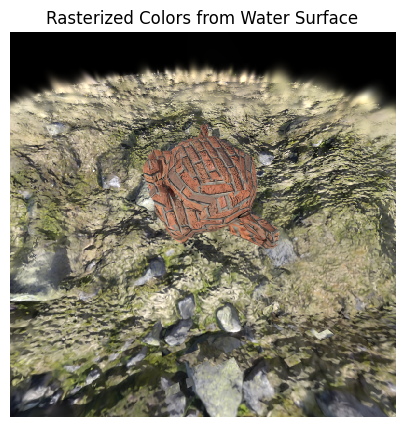

In [481]:
render_rgb, render_alpha, _ = rasterization(
    means=t_means,
    scales=t_scales,
    quats=t_quats,
    opacities=opacities,
    colors=colors,
    viewmats=worldtocam[0].unsqueeze(0),
    Ks=K[0].unsqueeze(0),
    width=width,
    height=height,
    sh_degree=0
)
# render_rgb shape, (1, height, width, 3) [0,1]の範囲のRGB値

img = render_rgb.squeeze().detach().cpu().numpy() # (height, width, 3) 長さ1の次元を消去 (dimを指定しなければすべて消去する)

plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Rasterized Colors from Water Surface')
plt.show()


In [482]:
spec_ratio, spec, trans = WS.schlick_fresnel_reflectance()
print(f"spec_ratio : {spec_ratio}") # (height, width
# trans: (height, width, 1) 透過率
# spec: (height, width, 1) 反射率

env_rgb = refrected_env_colors         # (height, width, 3)

cos_theta_i:
 tensor([[0.0508, 0.0508, 0.0509,  ..., 0.0509, 0.0509, 0.0508],
        [0.0518, 0.0518, 0.0519,  ..., 0.0519, 0.0519, 0.0518],
        [0.0528, 0.0528, 0.0528,  ..., 0.0529, 0.0528, 0.0528],
        ...,
        [0.8041, 0.8048, 0.8055,  ..., 0.8062, 0.8055, 0.8048],
        [0.8043, 0.8050, 0.8057,  ..., 0.8064, 0.8057, 0.8050],
        [0.8046, 0.8053, 0.8060,  ..., 0.8067, 0.8060, 0.8053]],
       device='cuda:0')
spec_ratio : 0.020059317350387573


In [483]:

reflected_img = trans * render_rgb * render_alpha\
    +  spec * env_rgb

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.025027465..1.0691025].


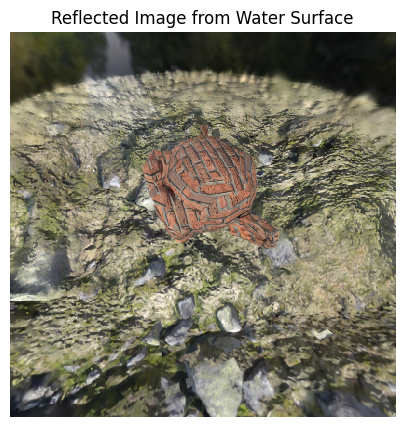

In [484]:
# show
plt.figure(figsize=(10, 5))
plt.imshow(reflected_img.squeeze().detach().cpu().numpy())
plt.axis('off')
plt.title('Reflected Image from Water Surface')
plt.show()


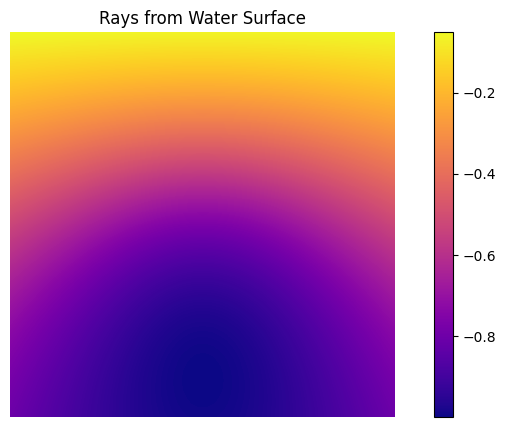

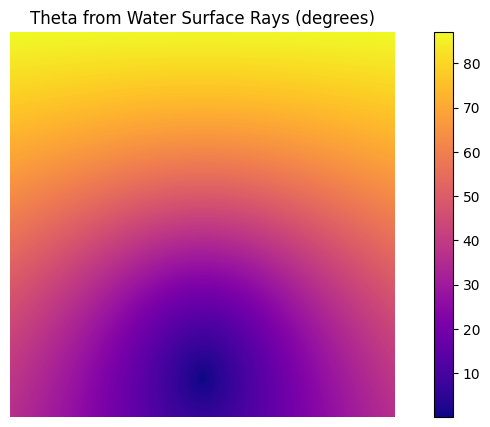

In [485]:
rays = WS.rays

# show rays as color map 
rays_np = rays.cpu().numpy()
plt.figure(figsize=(10, 5))
plt.imshow(rays_np[:, :, 2])
plt.axis('off')
plt.title('Rays from Water Surface')
plt.set_cmap('plasma')
plt.colorbar()
plt.show()

theta = np.arccos(-rays_np[:, :, 2]) * 180 / np.pi
plt.figure(figsize=(10, 5))
plt.imshow(theta, cmap='plasma')
plt.axis('off')
plt.title('Theta from Water Surface Rays (degrees)')
plt.colorbar()
plt.show()


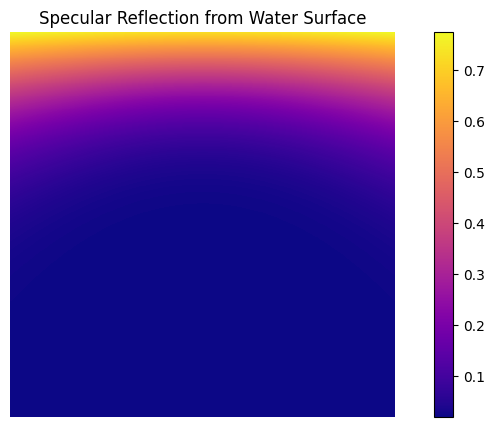

In [486]:
# show spec as
plt.figure(figsize=(10, 5))
plt.imshow(spec.squeeze().detach().cpu().numpy(), cmap='plasma')
plt.axis('off')
plt.title('Specular Reflection from Water Surface')
plt.colorbar()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02422528..1.0662191].


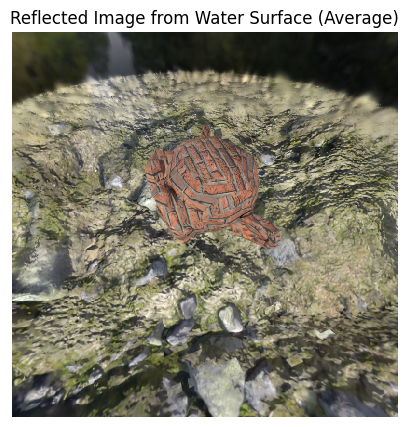

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.025027465..1.0691025].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02422528..1.0662191].


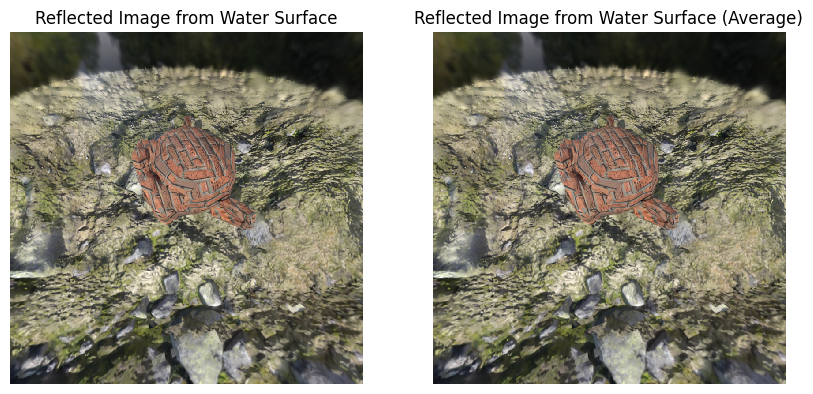

In [487]:
spec_ave, trans_ave = WS.fresnel_reflectance()

reflected_img_ave = trans_ave * render_rgb * render_alpha\
    +  spec_ave * env_rgb
    
# show
plt.figure(figsize=(10, 5))
plt.imshow(reflected_img_ave.squeeze().detach().cpu().numpy())
plt.axis('off')
plt.title('Reflected Image from Water Surface (Average)')
plt.show()

# compare two images 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(reflected_img.squeeze().detach().cpu().numpy())
plt.axis('off')
plt.title('Reflected Image from Water Surface')
plt.subplot(1, 2, 2)
plt.imshow(reflected_img_ave.squeeze().detach().cpu().numpy())
plt.axis('off')
plt.title('Reflected Image from Water Surface (Average)')
plt.show()



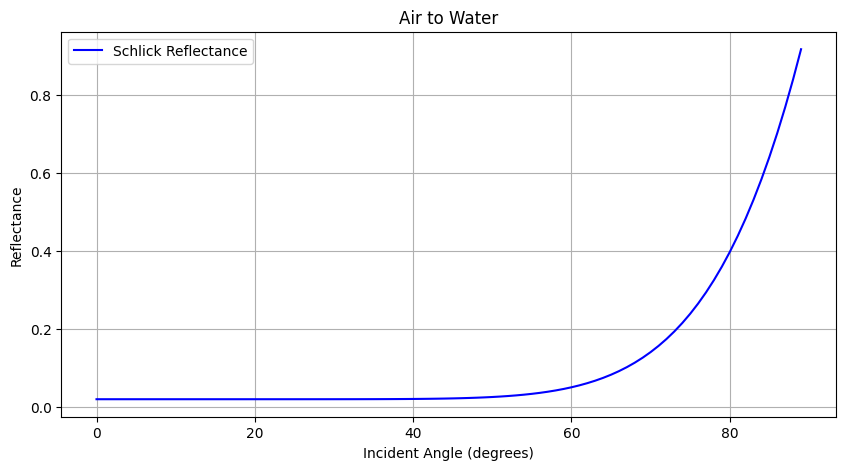

In [488]:
# plot the incident angle and reflaction ratio
incident_angle = np.arange(0, 90, 1)
incident_angle_rad = np.radians(incident_angle)

def schlick_reflectance(incident_angle_rad, n1=1.0, n2=1.33):
    r0 = ((n1 - n2) / (n1 + n2)) ** 2
    return r0 + (1 - r0) * (1 - np.cos(incident_angle_rad)) ** 5

reflectance = schlick_reflectance(incident_angle_rad)
plt.figure(figsize=(10, 5))
plt.plot(incident_angle, reflectance, label='Schlick Reflectance', color='blue')
plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Reflectance')
plt.title('Air to Water')
plt.grid()
plt.legend()
plt.show()


In [505]:
def Fr(theta_i, n_i=1.33, n_t=1.0):
    # sin(theta_t) = (n_i / n_t) * sin(theta_i)
    k = n_i / n_t * np.sin(theta_i)
    # clip to [-1, +1] to avoid invalid values in arcsin
    k_clipped = np.clip(k, -1.0, 1.0)
    theta_t = np.arcsin(k_clipped)

    # Fresnel for horizontal/parallel polarization
    f_h = ((n_t * np.cos(theta_i) - n_i * np.cos(theta_t)) /
           (n_t * np.cos(theta_i) + n_i * np.cos(theta_t)))**2
    # Fresnel for vertical/perpendicular polarization
    f_v = ((n_i * np.cos(theta_t) - n_t * np.cos(theta_i)) /
           (n_i * np.cos(theta_t) + n_t * np.cos(theta_i)))**2

    # average the two
    R = (f_h + f_v) / 2.0

    # total internal reflection where k > 1
    return np.where(k >= 1.0, 1.0, R)

Fr(np.radians(0))



array(0.02005931)

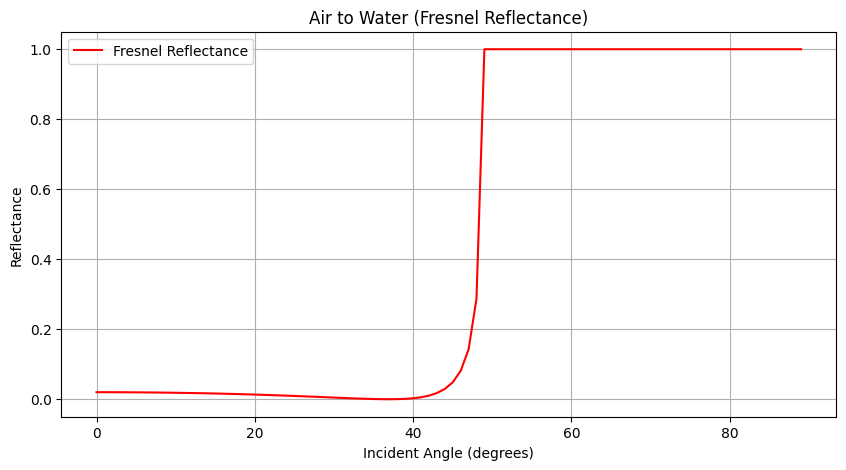

In [506]:
# plot
incident_angle = np.arange(0, 90, 1)
incident_angle_rad = np.radians(incident_angle)
reflectance = Fr(incident_angle_rad)
plt.figure(figsize=(10, 5))
plt.plot(incident_angle, reflectance, label='Fresnel Reflectance', color='red')
plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Reflectance')
plt.title('Air to Water (Fresnel Reflectance)')
plt.grid()
plt.legend()
plt.show()